## Imports

In [1]:
import pandas as pd
import os
from pathlib import Path
from reload_recursive import reload_recursive
from tqdm.notebook import tqdm

os.chdir("/home/srs-9/Projects/prl_project/src")
from helpers.parallel import BetterPool

from collections import defaultdict

import scripts.compile_run_metrics
import helpers.utils
import scripts.inference
from IPython.display import clear_output

In [2]:
reload_recursive(scripts.compile_run_metrics)
#TODO Thi
from scripts.compile_run_metrics import EXPERIMENT_KEYS

reload_recursive(scripts.inference)
from scripts.inference import uncrop_predictions

import analysis.image
reload_recursive(analysis.image)
from analysis.image import lesion_analysis as lesion_dx
from analysis.image import classify

reload_recursive(helpers.utils)
from helpers.utils import dice_score, get_prl_indices

import helpers.shell_interface
reload_recursive(helpers.shell_interface)
from helpers.shell_interface import open_itksnap_workspace_cmd

import core.dataset
reload_recursive(core.dataset)
from core.dataset import Dataset

import core.experiment
reload_recursive(core.experiment)
from core.experiment import Experiment
from loguru import logger

import scripts
reload_recursive(scripts)
# from scripts import lesion_diagnostics as lesion_dx
from scripts.compile_run_metrics import load_or_cache_run

In [3]:
analysis_dir = Path("/home/srs-9/Projects/prl_project/analysis")

In [4]:
# from radiomics import featureextractor, getTestCase
# import six

# params = "/home/srs-9/Projects/prl_project/notebooks/tmp/radiomics_params.yaml"
# extractor = featureextractor.RadiomicsFeatureExtractor(params)
# maskName = "/media/smbshare/srs-9/prl_project/inference_data/sub1126-20170609/4/flair.phase_xy20_z2_infer_stage6_sweep_dicece_wts_run1.nii.gz"
# imageName = "/media/smbshare/srs-9/prl_project/inference_data/sub1126-20170609/4/phase_xy20_z2.nii.gz"
# result = extractor.execute(imageName, maskName)

# for key, val in six.iteritems(result):
#   print("\t%s: %s" %(key, val))

In [5]:
# def extract_radiomic_features(maskName, imageName, params_file=None):
#     extractor = featureextractor.RadiomicsFeatureExtractor(params_file)
#     maskName = "/media/smbshare/srs-9/prl_project/inference_data/sub1126-20170609/4/flair.phase_xy20_z2_infer_stage6_sweep_dicece_wts_run1.nii.gz"
#     imageName = "/media/smbshare/srs-9/prl_project/inference_data/sub1126-20170609/4/phase_xy20_z2.nii.gz"
#     result = extractor.execute(imageName, maskName)
#     features = {
#         k[len("original_"):]: float(v) for k,v in result.items() if k.startswith("original_")
#     }
#     return features

In [6]:
# params1 = "/home/srs-9/Projects/prl_project/notebooks/tmp/radiomics_params1.yaml"
# extractor1 = featureextractor.RadiomicsFeatureExtractor(params1)
# result1 = extractor1.execute(imageName, maskName)

# for key, val in six.iteritems(result1):
#   print("\t%s: %s" %(key, val))

## Analysis

### Inference Set 1

In [7]:
data = pd.read_csv("/home/srs-9/Projects/thalamus_project/data/working_data_wide3.csv", index_col="subid")
train_dataset_name = "roi_train2"
train_dataset = Dataset(train_dataset_name)

experiment_key, run_name = "stage6", "run1"
experiment_name = f"{EXPERIMENT_KEYS[experiment_key]}/{run_name}"
experiment_name = "sweep_dicecewts/run1"
experiment_name = "test_dicece_lambda/run1"
experiment = Experiment.from_run_dir(experiment_name, train_dataset)
experiment_name = experiment.name.replace("/", "_")


expand_xy: int = experiment.preprocess_config.expand_xy
expand_z: int = experiment.preprocess_config.expand_z
images: tuple[str, ...] = experiment.preprocess_config.images

train_radiomic_df = pd.read_csv(
    analysis_dir / f"prl_image_stats-{train_dataset_name}_{experiment_name}-{train_dataset_name}.csv"
)

inference_dataset = Dataset("inference_dataset")
datafile_name = f"prl_image_stats-{train_dataset_name}_{experiment_name}-{inference_dataset.name}.csv"
inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)

# full_inference_dataset = Dataset("full_inference_dataset")
# datafile_name = f"prl_{full_inference_dataset.name}_image_stats-{train_dataset_name}_{experiment_name}.csv"
# full_inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)

# these are already filtered for "has_iron_infer"
large_train_df = pd.concat([train_radiomic_df, inf_radiomics_df], axis=0, ignore_index=True)

In [11]:
train_dataset.work_home

PosixPath('/media/smbshare/srs-9/prl_project/training/roi_train2')


--- Test set ---
              precision    recall  f1-score   support

      Lesion       0.89      0.88      0.89        86
         PRL       0.75      0.77      0.76        39

    accuracy                           0.85       125
   macro avg       0.82      0.83      0.82       125
weighted avg       0.85      0.85      0.85       125

ROC-AUC: 0.860


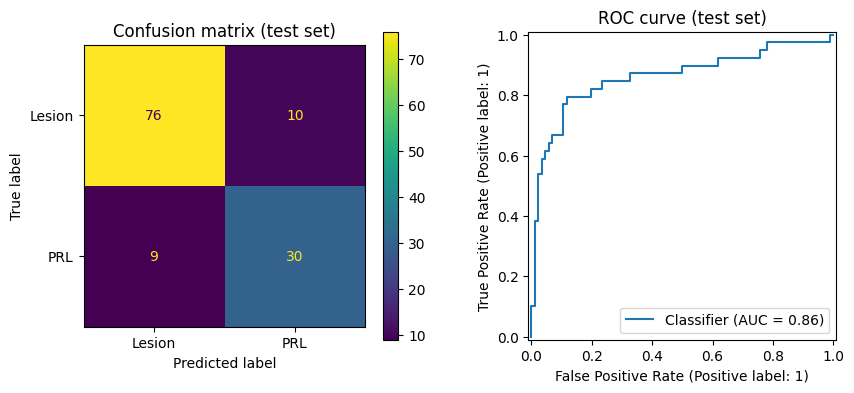

In [10]:
X_train, X_test, y_train, y_test = classify.prepare_data(large_train_df)
model = classify.train_model(X_train, y_train)
fig, axes = classify.evaluate_model(model, X_test, y_test, display=True, to_print=True, return_fig=True)

In [143]:
fig.savefig("classifier pereformance.png", dpi=600, transparent=True)

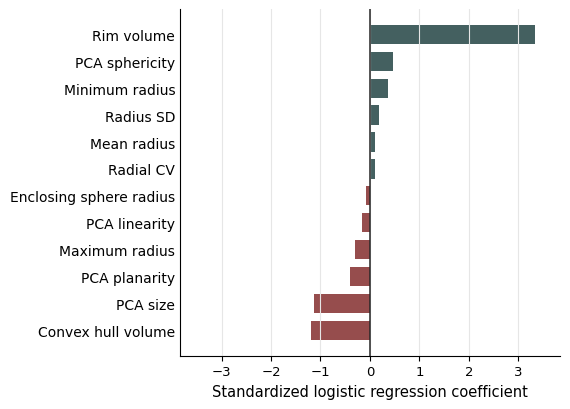

In [14]:
fig, ax, coef_df = classify.plot_logistic_coefficients(
    model,
    # title="Radiomic classifier feature weights",
    sort_by="coef",
    figsize=(5.8, 4.2),
    savepath="radiomic_classifier_coefficients.png",
)


--- Test set ---
              precision    recall  f1-score   support

      Lesion       0.91      0.84      0.87        99
         PRL       0.67      0.80      0.73        40

    accuracy                           0.83       139
   macro avg       0.79      0.82      0.80       139
weighted avg       0.84      0.83      0.83       139

ROC-AUC: 0.880

--- Feature coefficients (log-odds) ---
                feature      coef
       rim_volume_infer  2.561644
             std_radius  1.015812
         pca_sphericity  0.926491
  rim_hull_volume_infer -0.717702
            mean_radius -0.524004
             max_radius -0.467213
             min_radius  0.378389
          pca_linearity -0.236874
rim_sphere_radius_infer -0.234414
          pca_planarity -0.160162
              radial_cv -0.095186
               pca_size -0.055784


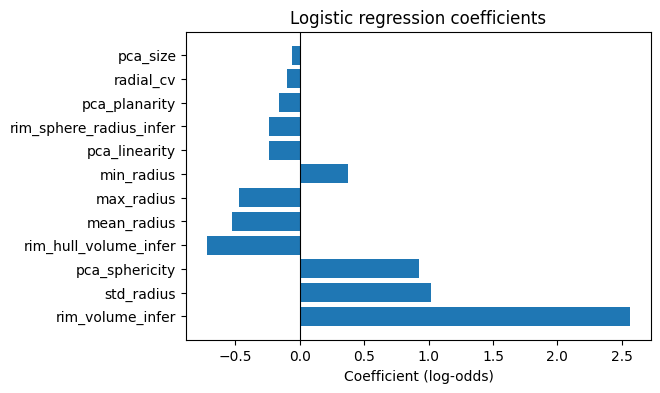

In [144]:
fig, axes = classify.evaluate_model(model, X_test, y_test, display_coef=True, to_print=True, return_fig=True)

In [145]:
fig.savefig("classification_feature_coefficients.png", dpi=600, transparent=True)

In [75]:
# Go down as far as it will allow on test size to create the model I will apply to the other full dataset
X_train, _, y_train, _ = classify.prepare_data(large_train_df, test_size=0)

# ik this is double dipping, but its just so I can get volumes of rim, not to evaluate model performance
all_subject_radiomics = pd.concat([large_train_df, full_inf_radiomics_df], axis=0, ignore_index=True)
_, X_test, _, y_test = classify.prepare_data(all_subject_radiomics, test_size=1)

model = classify.train_model(X_train, y_train)
y_pred, y_prob = classify.evaluate_model(model, X_test, y_test)
all_subject_radiomics['isPRL_infer'] = y_pred
all_subject_radiomics['isPRL_prob'] = y_prob

In [77]:
final_rim_volumes = all_subject_radiomics[all_subject_radiomics['isPRL_infer']==1].groupby("subid")['rim_volume_infer'].sum()
final_lesion_volumes = all_subject_radiomics[all_subject_radiomics['isPRL_infer']==1].groupby("subid")['lesion_volume_infer'].sum()

df = full_inference_dataset.prl_df.copy()
df['rim_volume'] = 0.0
df.loc[final_rim_volumes.index, 'rim_volume'] = final_rim_volumes

df['nPRL_infer'] = 0
df['nPRL_infer'] = all_subject_radiomics.groupby("subid")['isPRL_infer'].sum()

In [78]:
df.loc[1126, :]

PRL_possible              2
PRL_probable              3
PRL_definite             11
PRL                    14.0
date_mri           20170609
Total PRL              14.0
PRL1_label             23.0
PRL2_label              5.0
PRL3_label             18.0
PRL4_label             15.0
PRL5_label              6.0
PRL6_label             13.0
PRL7_label              4.0
PRL8_label              7.0
PRL9_label              1.0
PRL10_label             2.0
PRL11_label             2.0
PRL12_label             2.0
PRL13_label             2.0
PRL14_label             2.0
PRL15_label             1.0
PRL16_label             9.0
PRL17_label             NaN
PRL18_label             NaN
PRL19_label             NaN
PRL20_label             NaN
confidence.0       definite
confidence.1       definite
confidence.2       definite
confidence.3       possible
confidence.4       definite
confidence.5       probable
confidence.6       definite
confidence.7       probable
confidence.8       definite
confidence.9       d

[Text(0, 0, ''),
 Text(1, 0, ''),
 Text(2, 0, ''),
 Text(3, 0, ''),
 Text(4, 0, ''),
 Text(5, 0, ''),
 Text(6, 0, ''),
 Text(7, 0, ''),
 Text(8, 0, ''),
 Text(9, 0, ''),
 Text(10, 0, ''),
 Text(11, 0, ''),
 Text(12, 0, ''),
 Text(13, 0, '')]

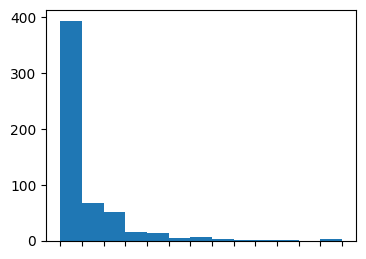

In [79]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, figsize=(4,3))
ax.hist(df['PRL'], bins=np.arange(0, 14, 1))
# plt.axes(visible=False)
# ax.set_yticklabels([])
ax.set_xticks(np.arange(0, 14, 1))
ax.set_xticklabels([])
# fig.savefig("PRL hist.png", transparent=True, dpi=600)

In [80]:
all_subject_radiomics

,subid,lesion_index,case_type,has_iron_infer,rim_voxels_infer,rim_volume_infer,rim_hull_volume_infer,rim_sphere_radius_infer,lesion_voxels_infer,lesion_volume_infer,...,pca_sphericity,pca_planarity,pca_linearity,mean_radius,std_radius,min_radius,max_radius,radial_cv,isPRL_infer,isPRL_prob
0,1033,2,PRL,True,304,155.647610,263.593991,6.260826,530,271.359300,...,0.563239,0.235150,0.201611,4.632045,1.231196,1.825990,7.664771,0.265800,1,0.883458
1,1033,1,Lesion,True,188,96.255760,243.711375,6.075049,644,329.727170,...,0.607194,0.115690,0.277116,4.474779,1.096146,2.176598,8.306837,0.244961,1,0.800010
2,1074,3,PRL,True,197,100.864380,141.909868,6.400752,276,141.312530,...,0.534251,0.139800,0.325950,3.816908,1.067341,0.549678,7.825353,0.279635,1,0.714015
3,1074,1,PRL,True,252,129.024490,159.488601,4.470342,268,137.216520,...,0.766027,0.117895,0.116078,3.881663,0.735932,1.896693,5.601359,0.189592,1,0.943135
4,1074,2,Lesion,True,18,9.216035,2.389342,2.469522,558,285.697080,...,0.210506,0.355478,0.434016,1.542056,0.642017,0.566558,3.053029,0.416338,0,0.091187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,3021,79,NaN,True,1,0.512002,NaN,0.000000,49,25.088095,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0,0.069449
2189,3028,1,NaN,True,318,162.816090,74438.948604,67.915074,28959,14827.016000,...,0.375684,0.305151,0.319166,37.973837,18.402679,10.187651,102.025688,0.484615,0,0.000127
2190,3028,3,NaN,True,53,27.136013,124.501395,14.423791,3214,1645.568800,...,0.406618,0.150507,0.442875,3.168959,2.450302,0.323518,18.848226,0.773220,0,0.133278
2191,3028,2,NaN,True,142,72.704040,41641.151143,53.861621,26672,13656.071000,...,0.268530,0.173834,0.557636,32.683382,15.532906,10.422283,71.731925,0.475254,0,0.005578


In [81]:
df['nPRL_diff'] = all_subject_radiomics.groupby("subid")['isPRL_infer'].sum() - all_subject_radiomics.groupby("subid")['has_iron_infer'].sum()

In [82]:
df.sort_values(by="nPRL_diff")

,PRL_possible,PRL_probable,PRL_definite,PRL,date_mri,Total PRL,PRL1_label,PRL2_label,PRL3_label,PRL4_label,...,confidence.13,confidence.14,confidence.15,confidence.16,confidence.17,confidence.18,confidence.19,rim_volume,nPRL_infer,nPRL_diff
subid,,,,,,,,,,,,,,,,,,,,,
1239,2,6,7,13.0,20170113,13.0,12.0,7.0,8.0,NaN,...,definite,probable,possible,NaN,NaN,NaN,NaN,1578.060132,10.0,-26.0
1405,4,2,4,6.0,20190407,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,773.638080,8.0,-19.0
1129,2,4,0,4.0,20200120,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1031.664088,11.0,-18.0
3021,0,0,0,0.0,20161117,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,-17.0
1346,1,0,0,0.0,20201012,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.349880,2.0,-14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3012,NaN,NaN,NaN,NaN,20200606,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
3014,NaN,NaN,NaN,NaN,20161214,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
3018,NaN,NaN,NaN,NaN,20170530,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN


---

Pyradiomics

In [36]:
train_radiomic_df = pd.read_csv(
    analysis_dir / f"prl_image_stats-{train_dataset_name}_{experiment_name}.csv"
)
train_pyradiomic_df = pd.read_csv(
    "/home/srs-9/Projects/prl_project/notebooks/tmp/training_pyradiomics.csv"
)
train_pyradiomic_df = train_pyradiomic_df.merge(train_radiomic_df, on=["subid", "lesion_index"], how="outer")

inference_dataset = Dataset("inference_dataset")
datafile_name = f"prl_{inference_dataset.name}_image_stats-{train_dataset_name}_{experiment_name}.csv"
inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)
inf_pyradiomics_df = pd.read_csv(
    "/home/srs-9/Projects/prl_project/notebooks/tmp/inference_pyradiomics.csv"
)
# inf_pyradiomics_df['case_type'] = inf_radiomics_df['case_type']
inf_pyradiomics_df = inf_pyradiomics_df.merge(inf_radiomics_df, on=["subid", "lesion_index"], how="outer")


large_train_df = pd.concat([train_pyradiomic_df, inf_pyradiomics_df], axis=0, ignore_index=True)

In [37]:
large_train_df

,subid,lesion_index,shape_VoxelVolume,shape_MeshVolume,shape_SurfaceArea,shape_SurfaceVolumeRatio,shape_Compactness1,shape_Compactness2,shape_Sphericity,shape_SphericalDisproportion,...,lesion_hull_volume_infer,pca_size,pca_sphericity,pca_planarity,pca_linearity,mean_radius,std_radius,min_radius,max_radius,radial_cv
0,1010,1,278.006194,63.315100,628.082407,9.919947,0.002269,0.001830,0.122313,8.175751,...,311.810267,183.685737,0.559704,0.212678,0.227618,5.548969,1.326448,2.049933,8.611520,0.239044
1,1010,2,105.470810,17.194473,240.295859,13.975180,0.002604,0.002410,0.134070,7.458811,...,378.797421,28.343222,0.290595,0.070847,0.638558,2.805429,1.818331,0.692454,11.703824,0.648147
2,1010,3,274.433035,32.000121,619.570604,19.361508,0.001171,0.000487,0.078673,12.710782,...,224.684301,134.095789,0.412810,0.113634,0.473556,4.696380,1.549639,1.150458,8.118505,0.329964
3,1010,4,274.433035,32.000121,619.570604,19.361508,0.001171,0.000487,0.078673,12.710782,...,617.732492,88.657470,0.311612,0.190871,0.497518,4.064866,1.525486,0.311647,7.238869,0.375286
4,1010,7,334.836190,66.365659,769.389413,11.593186,0.001754,0.001094,0.103031,9.705840,...,43.264315,14.864051,0.327042,0.089323,0.583635,2.417550,0.599913,1.481741,3.659994,0.248149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,2207,3,130.560492,18.901405,293.653781,15.536082,0.002119,0.001596,0.116854,8.557668,...,151.381904,NaN,NaN,NaN,NaN,0.500000,0.000000,0.500000,0.500000,0.000000
550,2207,4,163.328616,31.914787,382.366089,11.980844,0.002408,0.002061,0.127252,7.858397,...,165.803292,74.506781,0.563527,0.203428,0.233045,3.573928,0.868523,1.500161,5.507614,0.243016
551,2207,5,107.520405,13.269383,246.948707,18.610413,0.001929,0.001322,0.109760,9.110778,...,227.158190,29.778792,0.345970,0.180138,0.473892,2.607334,0.939832,0.701740,5.010103,0.360457
552,2207,8,155.648587,23.637422,359.605425,15.213394,0.001956,0.001359,0.110762,9.028356,...,123.563132,58.149455,0.536702,0.112106,0.351192,2.997734,0.832053,1.365753,5.474421,0.277561


In [19]:
inference_dataset = Dataset("inference_dataset")
datafile_name = f"prl_{inference_dataset.name}_image_stats-{train_dataset_name}_{experiment_name}.csv"
inf_radiomics_df = pd.read_csv(analysis_dir/datafile_name)
inf_radiomics_df

,subid,lesion_index,case_type,has_iron_infer,rim_voxels_infer,rim_volume_infer,rim_hull_volume_infer,rim_sphere_radius_infer,lesion_voxels_infer,lesion_volume_infer,lesion_hull_volume_infer,pca_size,pca_sphericity,pca_planarity,pca_linearity,mean_radius,std_radius,min_radius,max_radius,radial_cv
0,1130,2,PRL,True,387,198.134600,325.275219,10.223349,1152,589.79600,859.351187,173.813093,0.453905,0.091454,0.454641,5.142968,1.706740,1.465791,11.752781,0.331859
1,1130,3,PRL,True,124,63.484990,87.974489,5.295910,1312,671.71210,986.747804,64.539057,0.440168,0.398985,0.160847,3.324114,1.105259,0.720410,5.962487,0.332497
2,1130,5,PRL,True,146,74.748450,80.038865,4.319382,186,95.22748,107.600223,67.532597,0.497350,0.233961,0.268689,3.207563,0.959032,0.800696,5.351739,0.298991
3,1130,7,Lesion,True,57,29.182615,27.732016,3.328447,200,102.39514,88.742452,30.837027,0.449350,0.364318,0.186332,2.345920,0.754109,0.660870,4.219617,0.321456
4,1130,14,Lesion,True,1,0.511976,NaN,0.000000,214,109.56280,87.206525,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,2168,7,Lesion,True,1,0.512003,NaN,0.000000,877,449.02686,534.616703,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN
438,2168,5,Lesion,True,48,24.576157,96.171273,5.276514,1298,664.58020,997.808956,47.884471,0.355931,0.037348,0.606721,4.222868,1.473826,1.650573,7.113325,0.349011
439,2168,10,Lesion,True,2,1.024007,NaN,6.039884,600,307.20193,454.232196,NaN,NaN,NaN,NaN,7.549834,0.000000,7.549834,7.549834,0.000000
440,2168,14,Lesion,True,2,1.024007,NaN,0.565687,300,153.60097,120.064757,NaN,NaN,NaN,NaN,0.707107,0.000000,0.707107,0.707107,0.000000


In [28]:
large_train_df

,subid,lesion_index,shape_VoxelVolume,shape_MeshVolume,shape_SurfaceArea,shape_SurfaceVolumeRatio,shape_Compactness1,shape_Compactness2,shape_Sphericity,shape_SphericalDisproportion,...,gldm_GrayLevelVariance,gldm_HighGrayLevelEmphasis,gldm_LargeDependenceEmphasis,gldm_LargeDependenceHighGrayLevelEmphasis,gldm_LargeDependenceLowGrayLevelEmphasis,gldm_LowGrayLevelEmphasis,gldm_SmallDependenceEmphasis,gldm_SmallDependenceHighGrayLevelEmphasis,gldm_SmallDependenceLowGrayLevelEmphasis,case_type
0,1293,1,1286.140704,118.421030,2928.499565,24.729557,0.000422,0.000063,0.039822,25.111644,...,21.302943,24.359873,2.177548,32.989650,2.137799,0.972175,0.782500,22.279316,0.757656,PRL
1,1074,3,131.072494,29.056110,308.950312,10.632886,0.003019,0.003238,0.147941,6.759474,...,8.882812,10.445312,2.773438,12.218750,2.765635,0.992198,0.691461,10.136773,0.683658,Lesion
2,1080,3,131.072494,29.056110,308.950312,10.632886,0.003019,0.003238,0.147941,6.759474,...,8.882812,10.445312,2.773438,12.218750,2.765635,0.992198,0.691461,10.136773,0.683658,PRL
3,2131,1,243.711375,51.498535,547.463850,10.630668,0.002268,0.001828,0.122272,8.178520,...,4.332763,5.827731,2.025210,6.852941,2.012648,0.987438,0.803586,5.631317,0.791024,PRL
4,1011,7,73.211596,14.420466,164.088786,11.378883,0.003871,0.005323,0.174606,5.727194,...,13.844296,16.125874,1.531469,16.657343,1.510533,0.979065,0.882673,16.008547,0.861737,Lesion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,1265,36,98.815747,9.173310,226.180813,24.656402,0.001521,0.000823,0.093694,10.673027,...,17.689602,20.025907,2.264249,59.341969,2.217655,0.984469,0.747265,10.260219,0.739500,Lesion
550,2095,8,215.551448,29.695924,497.549630,16.754812,0.001510,0.000810,0.093206,10.728880,...,11.277752,13.149644,2.477435,29.206651,2.451332,0.988135,0.772594,9.277345,0.764289,Lesion
551,1248,18,107.007726,17.279956,246.258669,14.251117,0.002523,0.002261,0.131257,7.618667,...,0.000000,1.000000,2.636364,2.636364,2.636364,1.000000,0.740431,0.740431,0.740431,Lesion
552,2207,12,114.688432,15.616059,265.826726,17.022651,0.002033,0.001468,0.113658,8.798330,...,0.000000,1.000000,2.571429,2.571429,2.571429,1.000000,0.749311,0.749311,0.749311,Lesion


In [29]:
X_train

array([[2.12200000e+03, 3.00000000e+00, 1.65885832e+02, ...,
        1.13465859e+01, 9.42355016e-01, 2.47925525e-01],
       [1.23400000e+03, 1.30000000e+01, 6.04133919e+01, ...,
        9.10213635e+00, 8.40313066e-01, 1.94272139e-01],
       [1.13000000e+03, 4.00000000e+00, 1.56664560e+02, ...,
        1.33001580e+01, 7.39048101e-01, 2.32736469e-01],
       ...,
       [1.25200000e+03, 3.00000000e+00, 8.45827189e+02, ...,
        3.72740452e+01, 5.18668761e-01, 3.14126590e-01],
       [2.08600000e+03, 6.00000000e+00, 1.20318204e+02, ...,
        2.40043428e+01, 9.53015101e-01, 5.09449098e-01],
       [1.07800000e+03, 4.00000000e+00, 1.05470810e+02, ...,
        1.33160330e+01, 8.83152408e-01, 2.65387814e-01]], shape=(415, 19))

In [32]:
large_train_df

,subid,lesion_index,shape_VoxelVolume,shape_MeshVolume,shape_SurfaceArea,shape_SurfaceVolumeRatio,shape_Compactness1,shape_Compactness2,shape_Sphericity,shape_SphericalDisproportion,...,gldm_GrayLevelVariance,gldm_HighGrayLevelEmphasis,gldm_LargeDependenceEmphasis,gldm_LargeDependenceHighGrayLevelEmphasis,gldm_LargeDependenceLowGrayLevelEmphasis,gldm_LowGrayLevelEmphasis,gldm_SmallDependenceEmphasis,gldm_SmallDependenceHighGrayLevelEmphasis,gldm_SmallDependenceLowGrayLevelEmphasis,case_type
0,1293,1,1286.140704,118.421030,2928.499565,24.729557,0.000422,0.000063,0.039822,25.111644,...,21.302943,24.359873,2.177548,32.989650,2.137799,0.972175,0.782500,22.279316,0.757656,PRL
1,1074,3,131.072494,29.056110,308.950312,10.632886,0.003019,0.003238,0.147941,6.759474,...,8.882812,10.445312,2.773438,12.218750,2.765635,0.992198,0.691461,10.136773,0.683658,Lesion
2,1080,3,131.072494,29.056110,308.950312,10.632886,0.003019,0.003238,0.147941,6.759474,...,8.882812,10.445312,2.773438,12.218750,2.765635,0.992198,0.691461,10.136773,0.683658,PRL
3,2131,1,243.711375,51.498535,547.463850,10.630668,0.002268,0.001828,0.122272,8.178520,...,4.332763,5.827731,2.025210,6.852941,2.012648,0.987438,0.803586,5.631317,0.791024,PRL
4,1011,7,73.211596,14.420466,164.088786,11.378883,0.003871,0.005323,0.174606,5.727194,...,13.844296,16.125874,1.531469,16.657343,1.510533,0.979065,0.882673,16.008547,0.861737,Lesion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,1265,36,98.815747,9.173310,226.180813,24.656402,0.001521,0.000823,0.093694,10.673027,...,17.689602,20.025907,2.264249,59.341969,2.217655,0.984469,0.747265,10.260219,0.739500,Lesion
550,2095,8,215.551448,29.695924,497.549630,16.754812,0.001510,0.000810,0.093206,10.728880,...,11.277752,13.149644,2.477435,29.206651,2.451332,0.988135,0.772594,9.277345,0.764289,Lesion
551,1248,18,107.007726,17.279956,246.258669,14.251117,0.002523,0.002261,0.131257,7.618667,...,0.000000,1.000000,2.636364,2.636364,2.636364,1.000000,0.740431,0.740431,0.740431,Lesion
552,2207,12,114.688432,15.616059,265.826726,17.022651,0.002033,0.001468,0.113658,8.798330,...,0.000000,1.000000,2.571429,2.571429,2.571429,1.000000,0.749311,0.749311,0.749311,Lesion


In [77]:
FEATURES = [
    "rim_volume_infer",
    "rim_hull_volume_infer",
    # "rim_sphere_radius_infer",
    "pca_size",
    "pca_sphericity",

    "pca_planarity",
    "pca_linearity",
    "mean_radius",
    "std_radius",
    # # "min_radius",
    # "max_radius",
    # "radial_cv",
]


--- Test set ---
              precision    recall  f1-score   support

      Lesion       0.91      0.87      0.89        99
         PRL       0.70      0.78      0.74        40

    accuracy                           0.84       139
   macro avg       0.80      0.82      0.81       139
weighted avg       0.85      0.84      0.84       139

ROC-AUC: 0.878


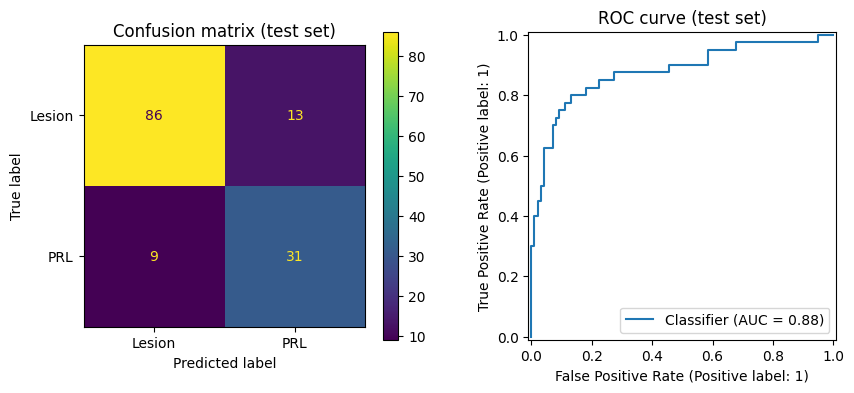

In [78]:
# features_names = [col for col in large_train_df.columns if col in FEATURES or col.startswith("glcm")]
# features_names = [col for col in large_train_df.columns if col not in ["subid", "lesion_index", "case_type"] and not col.startswith("shape_")]
features_names = [col for col in large_train_df.columns if col in FEATURES]

X_train, X_test, y_train, y_test = classify.prepare_data(large_train_df, features=features_names)
model = classify.train_model(X_train, y_train)
fig, axes = classify.evaluate_model(model, X_test, y_test, display=True, to_print=True, return_fig=True)

In [42]:
features_names

['glcm_Autocorrelation',
 'glcm_JointAverage',
 'glcm_ClusterProminence',
 'glcm_ClusterShade',
 'glcm_ClusterTendency',
 'glcm_Contrast',
 'glcm_Correlation',
 'glcm_DifferenceAverage',
 'glcm_DifferenceEntropy',
 'glcm_DifferenceVariance',
 'glcm_JointEnergy',
 'glcm_JointEntropy',
 'glcm_Imc1',
 'glcm_Imc2',
 'glcm_Idm',
 'glcm_Idmn',
 'glcm_Id',
 'glcm_Idn',
 'glcm_InverseVariance',
 'glcm_MaximumProbability',
 'glcm_SumEntropy',
 'glcm_SumSquares',
 'rim_volume_infer',
 'rim_hull_volume_infer',
 'rim_sphere_radius_infer',
 'pca_size',
 'pca_sphericity',
 'pca_planarity',
 'pca_linearity',
 'mean_radius',
 'std_radius',
 'min_radius',
 'max_radius',
 'radial_cv']

---

In [18]:
data.loc[1126, "PRL"]

np.float64(14.0)

In [83]:
from scripts.inference import uncrop_predictions

train_subjects = train_dataset.cases.index.get_level_values("subid").unique()
which_dataset = train_dataset
for subid in train_subjects.to_list():
    # subid = 1126
    check = all_subject_radiomics.set_index(["subid", "lesion_index"])
    subject_cases = check[check.index.get_level_values("subid")==subid]
    valid_indices = subject_cases.loc[subject_cases['isPRL_infer']==1, :].index.get_level_values("lesion_index")
    base_path = which_dataset.data_root
    subject_dir = base_path / which_dataset.subject(subid).dir
    expand_xy = experiment.preprocess_config.expand_xy
    expand_z = experiment.preprocess_config.expand_z
    images = experiment.preprocess_config.images
    run_id = experiment.name.replace("/", "_")
    suffix = "classed"

    uncrop_predictions(subject_dir, expand_xy, expand_z, which_dataset.data_root, images, run_id, suffix=suffix, valid_indices=valid_indices)

2026-05-22 04:07:58.329 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub1293-20161129/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:07:58.766 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub1074-20190518/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:07:59.581 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub1080-20180416/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:08:00.145 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/smbshare/srs-9/prl_project/data/sub2131-20190117/prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz
2026-05-22 04:08:00.762 | INFO     | scripts.inference:uncrop_predictions:378 - Saved uncropped prediction: /media/s

In [84]:
train_dataset.subject(1044)

Subject(1044, dir='sub1044-20170317')

In [85]:
train_dataset.subject(subid).dir

PosixPath('/media/smbshare/srs-9/prl_project/data/sub1358-20170311')

In [86]:
import nibabel as nib
import analysis.metrics
reload_recursive(analysis.metrics)
from analysis.metrics import performance

step1_performance = {}
step2_performance = {}
for subid in tqdm(train_subjects.to_list()):
    sub_dir = Path(f"{train_dataset.subject(subid).dir}")
    lab_path =  sub_dir / "prl_seg_def_prob.nii.gz"
    lab_data = nib.load(lab_path).get_fdata()

    inf_path = sub_dir / "prl_inference_stage6_sweep_dicece_wts_run1.nii.gz"
    inf_data = nib.load(inf_path).get_fdata()
    step1_performance[subid] = performance.binary_segmentation_metrics(lab_data, inf_data)

    inf_path = sub_dir / "prl_inference_stage6_sweep_dicece_wts_run1classed.nii.gz"
    inf_data = nib.load(inf_path).get_fdata()
    step2_performance[subid] = performance.binary_segmentation_metrics(lab_data, inf_data)

  0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
test_prl = train_dataset.cases[(train_dataset.cases.case_type=="PRL") & (train_dataset.cases.split == "testing")]

,,split,case_type,image,label,subject_dir
subid,lesion_index,,,,,
1293,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1293...,/media/smbshare/srs-9/prl_project/data/sub1293...,/media/smbshare/srs-9/prl_project/data/sub1293...
1074,3,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1074...,/media/smbshare/srs-9/prl_project/data/sub1074...,/media/smbshare/srs-9/prl_project/data/sub1074...
1080,3,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1080...,/media/smbshare/srs-9/prl_project/data/sub1080...,/media/smbshare/srs-9/prl_project/data/sub1080...
2131,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub2131...,/media/smbshare/srs-9/prl_project/data/sub2131...,/media/smbshare/srs-9/prl_project/data/sub2131...
1011,7,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1011...,/media/smbshare/srs-9/prl_project/data/sub1011...,/media/smbshare/srs-9/prl_project/data/sub1011...
1529,5,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...
2041,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub2041...,/media/smbshare/srs-9/prl_project/data/sub2041...,/media/smbshare/srs-9/prl_project/data/sub2041...
1348,1,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1348...,/media/smbshare/srs-9/prl_project/data/sub1348...,/media/smbshare/srs-9/prl_project/data/sub1348...
1529,11,testing,PRL,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...,/media/smbshare/srs-9/prl_project/data/sub1529...


In [87]:
step1_perf_df = pd.DataFrame(step1_performance).T
step1_perf_df.index.name="subid"
step1_perf_df = step1_perf_df.drop(columns=["tp", "fp", "tn", "fn", "sensitivity"])
print("### After SegResNet\n")
print(step1_perf_df.to_markdown())

### After SegResNet

|   subid |     dice |       f1 |   precision |   recall |   specificity |      npv |   accuracy |   hausdorff |   hausdorff95 |
|--------:|---------:|---------:|------------:|---------:|--------------:|---------:|-----------:|------------:|--------------:|
|    1293 | 0.286899 | 0.286899 |    0.189901 | 0.586441 |      0.999961 | 0.999994 |   0.999954 |    74.458   |      66.7001  |
|    1074 | 0.64891  | 0.64891  |    0.57265  | 0.748603 |      0.999991 | 0.999996 |   0.999987 |   114.865   |       1.73205 |
|    1080 | 0.570388 | 0.570388 |    0.451056 | 0.775578 |      0.999971 | 0.999993 |   0.999964 |    95.8019  |      90.9884  |
|    2131 | 0.722826 | 0.722826 |    0.621495 | 0.863636 |      0.999985 | 0.999996 |   0.999981 |    69.5845  |       1.52546 |
|    1011 | 0.643882 | 0.643882 |    0.542939 | 0.790932 |      0.999959 | 0.999987 |   0.999946 |    47.2758  |      27.313   |
|    1529 | 0.729159 | 0.729159 |    0.665032 | 0.806973 |      0.999978 | 0

In [227]:
step2_perf_df = pd.DataFrame(step2_performance).T
step2_perf_df.index.name="subid"
step2_perf_df = step2_perf_df.drop(columns=["tp", "fp", "tn", "fn", "sensitivity"])

print("### After Classification\n")
print(step2_perf_df.to_markdown())

### After Classification

|   subid |     dice |       f1 |   precision |   recall |   specificity |      npv |   accuracy |   hausdorff |   hausdorff95 |
|--------:|---------:|---------:|------------:|---------:|--------------:|---------:|-----------:|------------:|--------------:|
|    1293 | 0.336528 | 0.336528 |    0.245342 | 0.535593 |      0.999974 | 0.999993 |   0.999967 |    58.3866  |      52.1843  |
|    1074 | 0.663366 | 0.663366 |    0.595556 | 0.748603 |      0.999992 | 0.999996 |   0.999987 |     3       |       1.41421 |
|    1080 | 0.618014 | 0.618014 |    0.513661 | 0.775578 |      0.999977 | 0.999993 |   0.99997  |     4.3589  |       2.05902 |
|    2131 | 0.72628  | 0.72628  |    0.62662  | 0.863636 |      0.999985 | 0.999996 |   0.999981 |     3.74166 |       1.41421 |
|    1011 | 0.682361 | 0.682361 |    0.6      | 0.790932 |      0.999968 | 0.999987 |   0.999955 |     4.24264 |       1.41421 |
|    1529 | 0.738521 | 0.738521 |    0.680775 | 0.806973 |      0.99997

In [228]:
step2_perf_df - step1_perf_df

,dice,f1,precision,recall,specificity,npv,accuracy,hausdorff,hausdorff95
subid,,,,,,,,,
1293,0.049629,0.049629,0.055440,-0.050847,1.333354e-05,-7.935866e-07,1.253968e-05,-16.071400,-14.515803
1074,0.014456,0.014456,0.022906,0.000000,8.333471e-07,3.472334e-12,8.333333e-07,-111.865138,-0.317837
1080,0.047626,0.047626,0.062606,0.000000,6.533125e-06,4.570821e-11,6.532922e-06,-91.442980,-88.929429
2131,0.003454,0.003454,0.005124,0.000000,3.240833e-07,1.260325e-12,3.240741e-07,-65.842824,-0.111243
1011,0.038479,0.038479,0.057061,0.000000,8.488174e-06,1.087338e-10,8.487654e-06,-43.033146,-25.898787
1529,0.009363,0.009363,0.015743,0.000000,1.527861e-06,1.605793e-11,1.527778e-06,-32.711601,0.000000
2041,0.027316,0.027316,0.043979,-0.002116,6.991200e-06,-1.387656e-07,6.851852e-06,-57.684719,-7.732906
1348,-0.033478,-0.033478,0.041198,-0.209945,5.972322e-06,-3.518574e-06,2.453704e-06,-67.928639,-33.368523
1050,0.063277,0.063277,0.081197,0.000000,1.345367e-05,1.861403e-10,1.345316e-05,-34.907270,-13.829830


In [89]:
pd.concat([step1_perf_df.mean(), step2_perf_df.mean()], axis=1).T[['dice', 'precision', 'recall', 'hausdorff95']]

,dice,precision,recall,hausdorff95
0,0.600292,0.502330,0.766656,35.114652
1,0.631849,0.571725,0.738631,14.568240


In [93]:
stats.scoreatpercentile(step1_perf_df, 25)

np.float64(0.6476534170557364)

In [97]:
pd.concat([step1_perf_df.apply(stats.scoreatpercentile, args=([75])), step2_perf_df.apply(stats.scoreatpercentile, args=([75]))], axis=1).T[['dice', 'precision', 'recall', 'hausdorff95']]

,dice,precision,recall,hausdorff95
0,0.681130,0.600946,0.863105,60.928668
1,0.723259,0.646248,0.846684,23.281891


In [90]:
pd.concat([step1_perf_df.std(), step2_perf_df.std()], axis=1).T[['dice', 'precision', 'recall', 'hausdorff95']]

,dice,precision,recall,hausdorff95
0,0.129801,0.136790,0.118508,31.852791
1,0.128276,0.127521,0.151742,20.517869


In [10]:
df.to_csv(analysis_dir / "all_inferred_rim_volumes.csv")

In [1]:
full_inference_dataset.cases

NameError: name 'full_inference_dataset' is not defined